# Aging: Igkc OE — panels E, F and G

Recompute Igkc overexpression in all eligible young OL-WM cells (100%, value 45) from expression data using the Manual ROI. Panel G summarizes the saved immunoglobulin screen across four slice pairs.

Affected-cell ROI and 2x ROI are optional settings. Both baseline fitting and perturbation inference use positional encoding weight 0.1 and HVG log1p.

## 1. Imports


In [1]:
import os
import sys
from pathlib import Path
from typing import Optional

BASE_DIR = Path("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main")
sys.path.insert(0, str(BASE_DIR))

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

from brainbeacon.configs.config import DEFAULT_PATHS
from brainbeacon.pipeline.cell_embedding import run_brainbeacon_pipeline
from brainbeacon.pipeline.perturbation import (
    apply_gene_perturbation,
    analyze_embedding_similarity_change,
    analyze_embedding_similarity_change_similarity_niche,
    plot_cosine_to_centroids_with_perturb,
    plot_spatial_delta_cosine_after_perturbation,
)
from brainbeacon.tokenizer import set_seed

plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
})


/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Parameters, inputs and output directory


In [2]:
MODE = 'OE'
GENE = "Igkc"
TARGET_CELLTYPE = "OL-WM"
YOUNG_SLICE = "Hippocampus_Y_2_1"
OLD_SLICE = "Hippocampus_O_2_1"
ROI_MODE = 'manual_roi_1x'  # manual_roi_1x / affected_cell_roi / manual_roi_2x
SHOW_ALTERNATIVE_ROIS = False
OE_VALUE = 45
OE_PERCENT = 100
PERTURB_SEED = 0
SEED = 42
FIT_EPOCHS = 100
PE_WEIGHT = 0.1

adata_path = BASE_DIR / "data/adata_outer_ensembl.h5ad"
gene_dict_path = BASE_DIR / "prior_knowledge/gene_dict.h5ad"
stage1_ckpt_path = BASE_DIR / "prior_knowledge/ABL1_full_final_epoch_0_step_10000.pt"
stage2_ckpt_path = BASE_DIR / "prior_knowledge/stage2_epoch280_fit200.pt"
esm_path = BASE_DIR / "prior_knowledge/esm2_embeddings_d5120.pt"

DEFAULT_PATHS.update({
    "BASE_DIR": str(BASE_DIR),
    "PRIOR_DIR": str(BASE_DIR / "prior_knowledge"),
    "PRETRAIN_DIR": str(BASE_DIR / "pretrained"),
    "GENE_DICT_PATH": str(gene_dict_path),
    "ESM_EMBED_PATH": str(esm_path),
})
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
set_seed(SEED)

output_dir = BASE_DIR / "tutorial" / "outputs" / f"aging_{MODE.lower()}_{ROI_MODE}_maintext"
out_fig_dir = output_dir / "figures"
out_fig_dir.mkdir(parents=True, exist_ok=True)
slice_patch_size = ROI_MODE
species, assay = "mouse", "stereo"


### Model parameters


In [3]:
stage1_config = {'dim_model': 1024,
 'dim_feedforward': 1024,
 'nheads': 16,
 'nlayers': 16,
 'n_connect_comp': 46714,
 'use_esm_emb': True,
 'use_gene_id_emb': True,
 'use_homo_emb': True,
 'use_rna_type_emb': True,
 'use_gene_deviation': True,
 'use_cell_density': True,
 'use_dev_abs': True,
 'esm_emb_dim': 5120,
 'species': True,
 'assay': True,
 'n_hvg': 5000,
 'cd_weight': 0.02,
 'use_hvg': True,
 'weight_mode': 'expression',
 'force_tokenize': True,
 'hvg_log1p': True,
 'use_mean_norm': True,
 'radius_map': 'pretrain',
 'emb_layer': 'last',
 'expr_mode': None,
}
stage2_config = {'sampling_mode': 'spatial',
 'use_patch': False,
 'eval_use_patch': True,
 'max_eval_batch_size': 50000,
 'stage2_input_mode': 'raw',
 'pe_weight': PE_WEIGHT}


## 3. Load expression data


In [4]:
full_adata = sc.read_h5ad(adata_path)
adata = full_adata.copy()
def infer_cell_label(slice_name):
    if slice_name.startswith("Hippocampus_Y"): return "Young"
    if slice_name.startswith("Hippocampus_O"): return "Old"
    return None
adata.obs["cell_label"] = pd.Categorical(adata.obs["slice"].astype(str).map(infer_cell_label),categories=["Young","Old"])
adata.obs["batch"] = adata.obs["slice"]
adata_Y = adata[adata.obs["slice"].astype(str).eq(YOUNG_SLICE)].copy()
adata_O = adata[adata.obs["slice"].astype(str).eq(OLD_SLICE)].copy()
adata_young, adata_old = adata_Y, adata_O
print("Young:",adata_Y.shape,"| Old:",adata_O.shape)


Young: (3536, 20318) | Old: (6129, 20318)


## 4. Select the ROI

ROI_MODE controls both the model input and the displayed ROI. Bounds use open intervals.


In [5]:
roi_boxes = {'manual_roi_1x': {'plot_label': 'Manual ROI',
                   'young_x': (50.0, 78.0),
                   'young_y': (5.0, 25.0),
                   'old_x': (60.0, 88.0),
                   'old_y': (10.0, 30.0),
                   'linestyle': '-',
                   'color': '#145583'},
 'affected_cell_roi': {'plot_label': 'Affected-cell ROI',
                       'young_x': (65.0, 78.0),
                       'young_y': (12.0, 25.0),
                       'old_x': (78.0, 91.0),
                       'old_y': (16.0, 29.0),
                       'linestyle': '--',
                       'color': '#A13939'},
 'manual_roi_2x': {'plot_label': '2x ROI',
                   'young_x': (16.0, 72.0),
                   'young_y': (5.0, 45.0),
                   'old_x': (30, 88),
                   'old_y': (9.0, 49.0),
                   'linestyle': ':',
                   'color': '#2F7D32'}}

def roi_mask(data, x_range, y_range):
    xy = np.asarray(data.obsm["spatial"])
    return ((xy[:,0]>x_range[0])&(xy[:,0]<x_range[1])&
            (xy[:,1]>y_range[0])&(xy[:,1]<y_range[1]))
def subset_roi(data, x_range, y_range):
    return data[roi_mask(data,x_range,y_range)].copy()
cfg = roi_boxes[ROI_MODE]
ol_roi = subset_roi(adata_O,cfg["old_x"],cfg["old_y"])
y_roi = subset_roi(adata_Y,cfg["young_x"],cfg["young_y"])
roi_summary = pd.DataFrame([
    dict(ROI=c["plot_label"],young_cells=int(roi_mask(adata_Y,c["young_x"],c["young_y"]).sum()),
         old_cells=int(roi_mask(adata_O,c["old_x"],c["old_y"]).sum()),selected=k==ROI_MODE)
    for k,c in roi_boxes.items()])
display(roi_summary)
roi_summary.to_csv(output_dir/"ROI_options.csv",index=False)


,ROI,young_cells,old_cells,selected
0,Manual ROI,495,481,True
1,Affected-cell ROI,143,136,False
2,2x ROI,2007,2127,False


### Selected ROI on the whole slice


/tmp/ipykernel_3252852/976799596.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


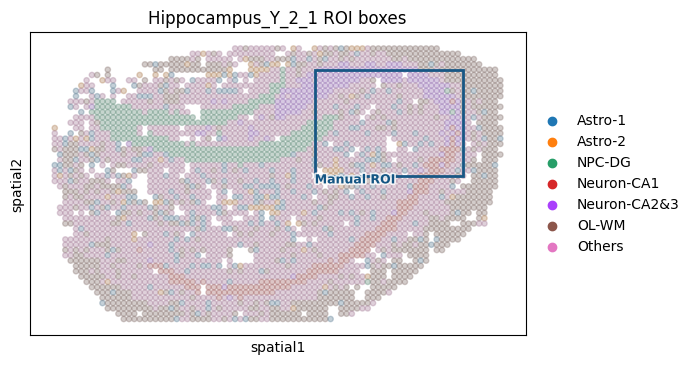

Saved PDF: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Hippocampus_Y_2_1_ROI_manual_roi_1x_colored.pdf
Saved SVG: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Hippocampus_Y_2_1_ROI_manual_roi_1x_colored.svg
Saved PNG: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Hippocampus_Y_2_1_ROI_manual_roi_1x_colored.png


/tmp/ipykernel_3252852/976799596.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


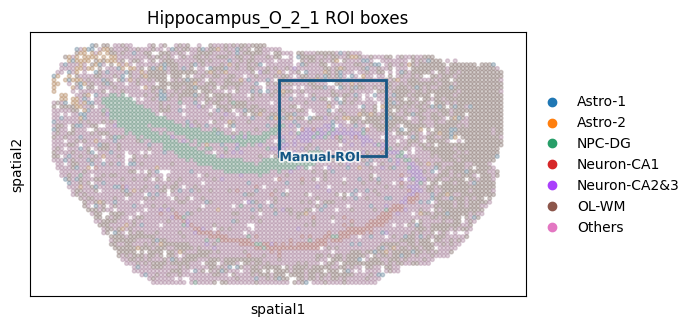

Saved PDF: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Hippocampus_O_2_1_ROI_manual_roi_1x_colored.pdf
Saved SVG: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Hippocampus_O_2_1_ROI_manual_roi_1x_colored.svg
Saved PNG: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Hippocampus_O_2_1_ROI_manual_roi_1x_colored.png


In [6]:
for part in [adata_Y,adata_O]:
    part.obs["cell_type"] = part.obs["cell_type"].astype("category")
    cats = part.obs["cell_type"].cat.categories
    part.uns["cell_type_colors"] = adata.uns.get("cell_type_colors",sc.pl.palettes.default_20[:len(cats)])
def mute_spatial_background(ax, blend=0.65, alpha=0.38):
    gray = np.array([0.55, 0.55, 0.55, 1.0])

    for c in ax.collections:
        facecolors = c.get_facecolor()
        if len(facecolors) > 0:
            muted = (1 - blend) * facecolors + blend * gray
            c.set_facecolor(muted)
            c.set_edgecolor(muted)
        c.set_alpha(alpha)

def plot_slice_with_rois(adata_slice, slice_name, side):
    fig = sc.pl.spatial(
        adata_slice,
        color="cell_type",
        spot_size=1,
        show=False,
        return_fig=True,
    )

    ax = fig.axes[0]
    mute_spatial_background(ax)

    for key, cfg in roi_boxes.items():
        if not SHOW_ALTERNATIVE_ROIS and key != ROI_MODE:
            continue
        x_min, x_max = cfg[f"{side}_x"]
        y_min, y_max = cfg[f"{side}_y"]

        rect = Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2.0,
            edgecolor=cfg["color"],
            facecolor="none",
            linestyle=cfg["linestyle"],
            alpha=0.98,
            zorder=10,
        )
        ax.add_patch(rect)

        ax.text(
            x_min,
            y_max + 2,
            cfg["plot_label"],
            fontsize=9,
            color=cfg["color"],
            weight="bold",
            ha="left",
            va="bottom",
            zorder=11,
            path_effects=[
                pe.withStroke(linewidth=2.5, foreground="white", alpha=0.85)
            ],
        )

    ax.set_title(f"{slice_name} ROI boxes")

    fig_path_pdf = os.path.join(out_fig_dir, f"{slice_name}_ROI_{ROI_MODE}_colored.pdf")
    fig_path_svg = os.path.join(out_fig_dir, f"{slice_name}_ROI_{ROI_MODE}_colored.svg")
    fig_path_png = os.path.join(out_fig_dir, f"{slice_name}_ROI_{ROI_MODE}_colored.png")

    fig.savefig(fig_path_pdf, bbox_inches="tight")
    fig.savefig(fig_path_svg, bbox_inches="tight")
    fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved PDF: {fig_path_pdf}")
    print(f"Saved SVG: {fig_path_svg}")
    print(f"Saved PNG: {fig_path_png}")

plot_slice_with_rois(adata_Y, YOUNG_SLICE, side="young")
plot_slice_with_rois(adata_O, OLD_SLICE, side="old")


### Igkc expression maps


/tmp/ipykernel_3252852/925648550.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig1 = sc.pl.spatial(


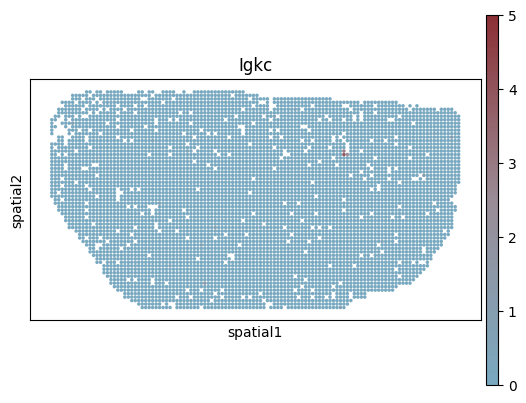

Saved to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Igkc_spatial_old——slice.pdf


In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# low: blue, middle: gray-purple, high: dark red
roi_cmap = LinearSegmentedColormap.from_list(
    "roi_blue_red",
    ["#79A9C0", "#9A8C96", "#8B2F34"]
)

gene = "Igkc"

fig1 = sc.pl.spatial(
    adata_old,
    color=gene,
    gene_symbols="gene_symbol",
    layer="lognorm" if "lognorm" in adata_old.layers else None,
    spot_size=1,
    cmap=roi_cmap,
    vmin=0,
    vmax=5,
    show=False,
    return_fig=True,
)
pdf_path = os.path.join(str(out_fig_dir), f"{gene}_spatial_old——slice.pdf")

fig1.savefig(

    pdf_path,

    bbox_inches="tight",

    dpi=500,

)

display(fig1)
plt.close(fig1)

print(f"Saved to: {pdf_path}")


/tmp/ipykernel_3252852/1997060184.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig1 = sc.pl.spatial(


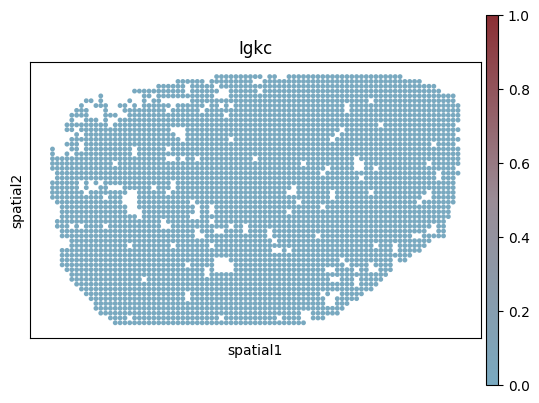

Saved to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/figures/Igkc_spatial_young_slice.pdf


In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# low: blue, middle: gray-purple, high: dark red
roi_cmap = LinearSegmentedColormap.from_list(
    "roi_blue_red",
    ["#79A9C0", "#9A8C96", "#8B2F34"]
)

gene = "Igkc"

fig1 = sc.pl.spatial(
    adata_young,
    color=gene,
    gene_symbols="gene_symbol",
    layer="lognorm" if "lognorm" in adata_young.layers else None,
    spot_size=1,
    cmap=roi_cmap,
    vmin=0,
    vmax=1,
    show=False,
    return_fig=True,
)


pdf_path = os.path.join(str(out_fig_dir), f"{gene}_spatial_young_slice.pdf")

fig1.savefig(

    pdf_path,

    bbox_inches="tight",

    dpi=500,

)

display(fig1)
plt.close(fig1)

print(f"Saved to: {pdf_path}")


## 5. Prepare the selected pair and fit the baseline


In [9]:
adata_fov_OL = ad.concat([ol_roi,y_roi],join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
adata_fov_OL.obs["split"] = "train"
for key in ["bb_emb","bb_emb_raw","X_emb","X_pred"]:
    if key in adata_fov_OL.obsm: del adata_fov_OL.obsm[key]
output_prefix_ori = "original"
ori_input_adata_path = str(output_dir/"original_input.h5ad")
adata_fov_OL.write_h5ad(ori_input_adata_path)
print("Selected model input:",adata_fov_OL.shape,"|",cfg["plot_label"])


Selected model input: (976, 20318) | Manual ROI


In [10]:
# ========== 6. Run Original Inference (Baseline) ==========
# Run the two-stage BrainBeacon pipeline on the unperturbed data.
# The resulting embedding / fitted stage2 ckpt will be the reference for all
# subsequent KO/OE analyses.

# Fit stage2 once here; the rolling ckpt is written to `rolling_stage2_ckpt_path`
# so later perturbation runs can reuse it with do_fit=False.
rolling_stage2_ckpt_path = str(output_dir / f"{output_prefix_ori}_cellformer.pt")

adata_ori = run_brainbeacon_pipeline(
    adata_path=str(ori_input_adata_path),
    species=species,
    assay=assay,
    gene_dict_path=str(gene_dict_path),
    stage1_ckpt_path=str(stage1_ckpt_path),
    stage2_ckpt_path=str(stage2_ckpt_path),
    output_dir=str(output_dir),
    output_prefix=output_prefix_ori,
    stage1_config=stage1_config,
    stage2_config=stage2_config,
    do_fit=True,
    fit_epochs=FIT_EPOCHS,
    save_model=True,
    save_model_path=rolling_stage2_ckpt_path,
    device=device,
    seed=SEED,
    deterministic=True,
)
print("Original reconstruction complete. Embeddings and rolling stage2 ckpt saved.")
print("adata_ori:", adata_ori)
print(f"rolling stage2 ckpt -> {rolling_stage2_ckpt_path}")

ori_result_adata_path = str(output_dir / f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")



====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...


/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


Computing cell density...
compute_density_token time: 0.0025 seconds


[Stage1 memory] Tokenization done: 976 cells, 5.6s
[Stage1 memory] Running inference (batch_size=64)...


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/brainbeacon/pipeline/cell_embedding.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental fe

...

100%|██████████| 100/100 [01:00<00:00,  1.81it/s]

100%|██████████| 100/100 [01:00<00:00,  1.65it/s]

Epoch 99 | Train loss: 4481.0161 | Valid loss: 4533.8746
After filtering, 20316 genes remain.


Model saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/original_stage2_embeddings.npz
Original reconstruction complete. Embeddings and rolling stage2 ckpt saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'split', 'platform', 'valid_split', 'x_FOV_px', 'y_FOV_px'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_

Original result adata saved to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/original_result.h5ad


## 6. Perturbation and inference

Set Igkc to 45 in all eligible young OL-WM cells.
Use the fitted baseline for perturbation inference.


In [11]:
perturbed_adata_final, perturbed_cells_final = apply_gene_perturbation(
    adata=adata_fov_OL,
    gene_list=[GENE],
    mode="overexpress",
    filter_by={
        "slice": "Hippocampus_Y_2_1",
        "cell_type": "OL-WM",
    },
    value=OE_VALUE,
    perturb_percent=OE_PERCENT,     # 100% of eligible young OL-WM cells
    random_state=PERTURB_SEED,
)
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s).")

# Save perturbed input AnnData
output_prefix_perturb = "oe_young_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# =============================================================================
# 8. Run perturbation inference
# =============================================================================
# The perturbed AnnData is passed through the pretrained BrainBeacon + CellFormer
# pipeline to reconstruct embeddings under the perturbed gene expression state.

cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_final = run_brainbeacon_pipeline(
    adata_path=perturb_input_adata_path,
    species=species,
    assay=assay,
    gene_dict_path=str(gene_dict_path),
    stage1_ckpt_path=str(stage1_ckpt_path),
    stage2_ckpt_path=rolling_stage2_ckpt_path,   # from baseline fit
    output_dir=str(output_dir),
    output_prefix=output_prefix_perturb,
    stage1_config=stage1_config,
    stage2_config=stage2_config,
    do_fit=False,
    fit_epochs=0,
    save_model=False,
    device=device,
    seed=SEED,
    deterministic=True,
)
print("Perturbation inference complete.")
print("adata_perturb:", adata_perturb_final)

perturb_result_adata_path = str(output_dir / f"{output_prefix_perturb}_result.h5ad")
adata_perturb_final.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")




========== apply_gene_perturbation ==========
mode: overexpress
genes input: ['Igkc']
genes resolved: ['ENSMUSG00000076609']
adata.n_vars: 20318
candidate cells before perturb expression filter: 39
perturbed cells: 39
perturb_percent: 100
actual fraction: 1.0000
random_state: 0
filter_by: {'slice': 'Hippocampus_Y_2_1', 'cell_type': 'OL-WM'}
Perturbed 39 cells: set expression of target gene(s).


/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Perturbed input adata saved to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/oe_young_final_input.h5ad


====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...


/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


...

[INFO] Loading stage2 pretrained checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/original_cellformer.pt
[INFO] Skipped parameters (0): []


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/brainbeacon/bbcellformer/pipeline/__init__.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimen

After filtering, 20316 genes remain.


Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/oe_young_final_stage2_embeddings.npz
Perturbation inference complete.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'split', 'platform', 'valid_split', 'x_FOV_px', 'y_FOV_px'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial', 'bb_emb', 'X_emb', 'X_pred'
    layers: 'lognorm', 'raw_count'


Perturbation result adata saved to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/aging_oe_manual_roi_1x_maintext/oe_young_final_result.h5ad


## 7. Target and niche statistics
Cosine similarity, Euclidean distance, Wasserstein distance and MMD use the source target/niche group definitions.


In [12]:
target_slice_young = YOUNG_SLICE
target_slice_old = OLD_SLICE
target_celltype = TARGET_CELLTYPE
# This block evaluates the effect of Igkc overexpression (OE) in young target cells.
# Specifically, it compares embedding similarity between:
#   (i) young vs old target cells before and after OE (cell-intrinsic effect), and
#   (ii) young target-cell niches vs old-cell niches before and after OE (niche-level effect).
# Metrics include cosine similarity, Euclidean distance, Wasserstein distance (EMD), and MMD.

# =============================================================================
# Cell-intrinsic similarity: target young cells vs old cells (before / after OE)
# =============================================================================
result_cell = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb",
    direction="OE",
)

cell_cosine_before, cell_cosine_after = result_cell["cosine"]
cell_euclid_before, cell_euclid_after = result_cell["euclidean"]
cell_emd_before, cell_emd_after = result_cell["emd"]
cell_mmd_before, cell_mmd_after = result_cell["mmd"]

print("Target cell (Young → Old) similarity after Igkc OE:")
print("  Cosine similarity        : before = {:.4f}, after = {:.4f}".format(cell_cosine_before, cell_cosine_after))
print("  Euclidean distance       : before = {:.4f}, after = {:.4f}".format(cell_euclid_before, cell_euclid_after))
print("  Wasserstein distance (EMD): before = {:.4f}, after = {:.4f}".format(cell_emd_before, cell_emd_after))
print("  MMD                      : before = {:.4f}, after = {:.4f}".format(cell_mmd_before, cell_mmd_after))

# =============================================================================
# 2. Niche-level similarity, explicit OE direction
# =============================================================================
result_niche_metrics = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb",
    direction="OE",
)

niche_cosine_before, niche_cosine_after = result_niche_metrics["cosine"]
niche_euclid_before, niche_euclid_after = result_niche_metrics["euclidean"]
niche_emd_before, niche_emd_after = result_niche_metrics["emd"]
niche_mmd_before, niche_mmd_after = result_niche_metrics["mmd"]

print("\nTarget cell niche (Young → Old) similarity after Igkc OE:")
print("  Cosine similarity        : before = {:.4f}, after = {:.4f}".format(niche_cosine_before, niche_cosine_after))
print("  Euclidean distance       : before = {:.4f}, after = {:.4f}".format(niche_euclid_before, niche_euclid_after))
print("  Wasserstein distance (EMD): before = {:.4f}, after = {:.4f}".format(niche_emd_before, niche_emd_after))
print("  MMD                      : before = {:.4f}, after = {:.4f}".format(niche_mmd_before, niche_mmd_after))


Target cell (Young → Old) similarity after Igkc OE:
  Cosine similarity        : before = 0.2735, after = 0.5902
  Euclidean distance       : before = 18.7382, after = 13.2535
  Wasserstein distance (EMD): before = 0.6549, after = 0.4639
  MMD                      : before = 0.1755, after = 0.3153

Target cell niche (Young → Old) similarity after Igkc OE:
  Cosine similarity        : before = 0.3324, after = 0.6656
  Euclidean distance       : before = 18.4548, after = 12.4846
  Wasserstein distance (EMD): before = 0.6325, after = 0.4217
  MMD                      : before = 0.1369, after = 0.1510


## 8. Cell-state positioning

Similarity to young and old centroids; stars show group means.


### E. All-cell state shift

========== plot_cosine_to_centroids_with_perturb ==========
direction              = OE
perturb_scope          = slice
exclude_celltype       = False
target_celltype        = OL-WM
young cells n          = 495
old cells n            = 481
perturbed plotted n    = 495
----------------------------------------------------------
young mean coord       = (0.893125, 0.328173)
old mean coord         = (0.364331, 0.991530)
perturbed mean coord   = (0.837214, 0.662138)


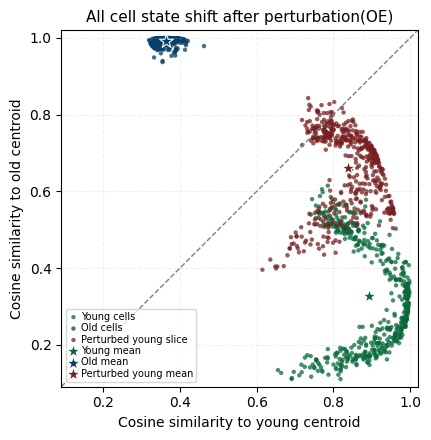

In [13]:
result_all = plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young=YOUNG_SLICE,
    slice_old=OLD_SLICE,
    target_celltype=TARGET_CELLTYPE,
    exclude_celltype=False,
    direction=MODE,
    perturb_scope="slice",
    show=False,
)

# C (KO) / E (OE): all-cell state positioning.
STATE_FIGSIZE = (4.5, 4.5)
STATE_DOT_SIZE = 10
STATE_LIMITS = None  # Optional (lower, upper); None keeps every computed point visible.
state_panel = "C" if MODE == "KO" else "E"
state_perturbed_color = "#6f8f94" if MODE == "KO" else "#791f1f"
state_side = "old" if MODE == "KO" else "young"
state_groups = [
    ("Young cells", "Young mean", "#076a3a", result_all["cos_young_young"], result_all["cos_old_young"]),
    ("Old cells", "Old mean", "#073f6a", result_all["cos_young_old"], result_all["cos_old_old"]),
    (f"Perturbed {state_side} slice", f"Perturbed {state_side} mean", state_perturbed_color,
     result_all["cos_young_perturbed"], result_all["cos_old_perturbed"]),
]
fig_state, ax_state = plt.subplots(figsize=STATE_FIGSIZE)
for label, _, color, x, y in state_groups:
    ax_state.scatter(x,y,s=STATE_DOT_SIZE,c=color,alpha=0.75,edgecolors="none",label=label)
for _, label, color, x, y in state_groups:
    ax_state.scatter(np.mean(x),np.mean(y),s=110,c=color,marker="*",edgecolors="white",linewidths=0.8,label=label)
state_values = np.concatenate([v for group in state_groups for v in group[-2:]])
lo, hi = STATE_LIMITS if STATE_LIMITS is not None else (float(state_values.min())-0.02,float(state_values.max())+0.02)
ax_state.plot([lo,hi],[lo,hi],ls="--",c="gray",lw=1)
ax_state.set(xlim=(lo,hi),ylim=(lo,hi),
    xlabel="Cosine similarity to young centroid",ylabel="Cosine similarity to old centroid")
ax_state.set_title(f"All cell state shift after perturbation({MODE})",fontsize=11)
ax_state.set_aspect("equal",adjustable="box")
ax_state.grid(alpha=0.20,ls="--")
ax_state.legend(loc="lower left",fontsize=7,frameon=True,handlelength=0.9,
    labelspacing=0.15,handletextpad=0.3,borderpad=0.3)
fig_state.tight_layout()
for ext in ["pdf","svg","png"]:
    fig_state.savefig(out_fig_dir / f"panel_{state_panel}_all_cell_state.{ext}",bbox_inches="tight",dpi=300)
plt.show()

state_table = pd.concat([
    pd.DataFrame({"group": label, "cosine_to_young": x, "cosine_to_old": y})
    for label, _, _, x, y in state_groups
], ignore_index=True)
state_table.to_csv(output_dir / f"panel_{state_panel}_cell_state_coordinates.csv", index=False)


### Niche (excluding OL-WM)


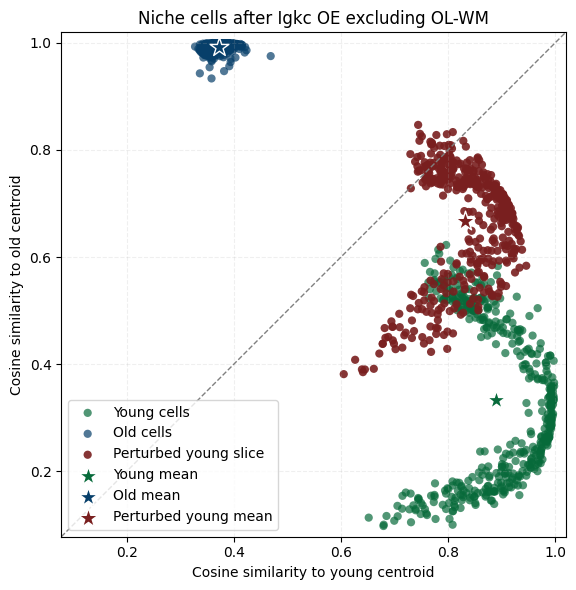

========== plot_cosine_to_centroids_with_perturb ==========
direction              = OE
perturb_scope          = slice
exclude_celltype       = True
target_celltype        = OL-WM
young cells n          = 456
old cells n            = 393
perturbed plotted n    = 456
----------------------------------------------------------
young mean coord       = (0.889392, 0.333060)
old mean coord         = (0.371474, 0.991971)
perturbed mean coord   = (0.832226, 0.666465)


In [14]:
result_niche = plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=True,
    direction="OE",
    perturb_scope="slice",
    title="Niche cells after Igkc OE excluding OL-WM",
    # save_path=os.path.join(str(out_fig_dir), "niche_cell_cell_stat.pdf"),
    save_path=str(out_fig_dir/"niche_state.pdf"),
)


### Actually perturbed cells


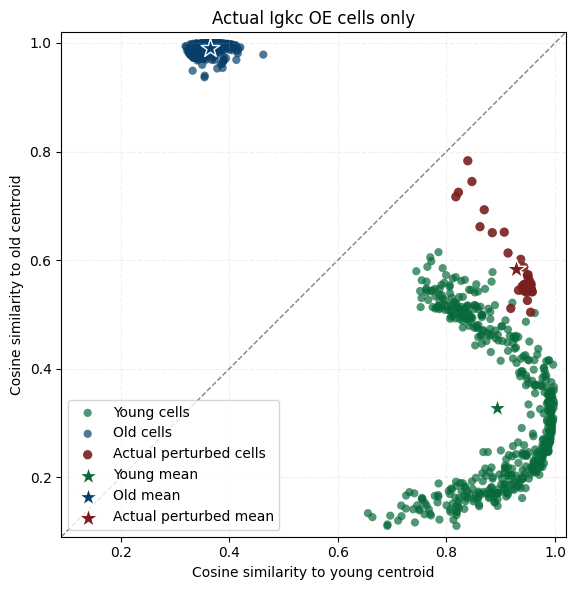

========== plot_cosine_to_centroids_with_perturb ==========
direction              = OE
perturb_scope          = highlight
exclude_celltype       = False
target_celltype        = OL-WM
young cells n          = 495
old cells n            = 481
perturbed plotted n    = 39
----------------------------------------------------------
young mean coord       = (0.893125, 0.328173)
old mean coord         = (0.364331, 0.991530)
perturbed mean coord   = (0.928799, 0.583544)


In [15]:
result_actual_perturb = plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    highlight_cells=perturbed_cells_final,
    exclude_celltype=False,
    direction="OE",
    perturb_scope="highlight",
    title="Actual Igkc OE cells only",
    # save_path=os.path.join(str(out_fig_dir), f"actual_OE_cell_cell_stat_targetcell_{slice_patch_size}.pdf"),
    save_path=str(out_fig_dir/"actual_perturbed_state.pdf"),
)


## F. Per-cell spatial Δ cosine

/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/brainbeacon/pipeline/perturbation.py:1395: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_3252852/3529994084.py:21: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


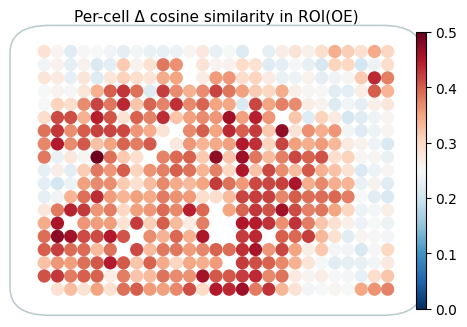

In [16]:
from matplotlib.patches import FancyBboxPatch
SPATIAL_FIGSIZE = (4.8, 3.3)
SPATIAL_VLIM = (-0.03, 0.13) if MODE == "KO" else (0.0, 0.5)
SPATIAL_CMAP = "RdBu_r"
SPATIAL_SPOT_SIZE = 1
spatial_panel = "D" if MODE == "KO" else "F"
adata_delta = plot_spatial_delta_cosine_after_perturbation(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_perturb=OLD_SLICE if MODE == "KO" else YOUNG_SLICE,
    slice_reference=YOUNG_SLICE if MODE == "KO" else OLD_SLICE,
    target_celltype=TARGET_CELLTYPE,
    highlight_cells=perturbed_cells_final,
    emb_key="X_emb",
    reference_mode="global_reference",
    show=False,
    verbose=False,
)
# D / F display every cell as a circle, without a target-star overlay.
fig_spatial, ax_spatial = plt.subplots(figsize=SPATIAL_FIGSIZE)
sc.pl.spatial(
    adata_delta,
    color="delta_cos_to_reference_global_reference",
    spot_size=SPATIAL_SPOT_SIZE,
    cmap=SPATIAL_CMAP,
    vmin=SPATIAL_VLIM[0], vmax=SPATIAL_VLIM[1],
    ax=ax_spatial, show=False, title="",
)
ax_spatial.set_title(f"Per-cell Δ cosine similarity in ROI({MODE})",fontsize=11,pad=8)
ax_spatial.set_axis_off()
ax_spatial.add_patch(FancyBboxPatch(
    (0,0),1,1,boxstyle="round,pad=0.025,rounding_size=0.10",
    transform=ax_spatial.transAxes,facecolor="none",edgecolor="#B9C9CC",
    linewidth=1.1,clip_on=False,zorder=20,
))
fig_spatial.tight_layout()
for ext in ["pdf","svg","png"]:
    fig_spatial.savefig(out_fig_dir / f"panel_{spatial_panel}_spatial_delta.{ext}",bbox_inches="tight",dpi=300)
plt.show()


## 10. Save result tables


In [17]:
# Save target/niche metrics and per-cell spatial changes.
metric_rows = []
for group,values in [("target",result_cell),("niche",result_niche_metrics)]:
    for metric,pair in values.items():
        if metric in ["cosine","euclidean","emd","mmd"]:
            before,after = pair
            metric_rows.append(dict(group=group,metric=metric,before=float(before),after=float(after),delta=float(after-before)))
metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(output_dir/"single_perturbation_metrics.csv",index=False)
display(metrics_df)
pd.Series(perturbed_cells_final,name="obs_name").to_csv(output_dir/"actually_perturbed_cells.csv",index=False)
spatial_columns = [c for c in adata_delta.obs if c.startswith("delta_cos") or c.startswith("is_")]
spatial_df = adata_delta.obs[spatial_columns].copy()
spatial_df["x"] = np.asarray(adata_delta.obsm["spatial"])[:,0]
spatial_df["y"] = np.asarray(adata_delta.obsm["spatial"])[:,1]
spatial_df.to_csv(output_dir/"single_spatial_delta.csv",index_label="obs_name")


,group,metric,before,after,delta
0,target,cosine,0.273478,0.590172,0.316694
1,target,euclidean,18.738201,13.253525,-5.484676
2,target,emd,0.654905,0.463904,-0.191001
3,target,mmd,0.175485,0.315266,0.139781
4,niche,cosine,0.332447,0.665580,0.333133
5,niche,euclidean,18.454752,12.484621,-5.970131
6,niche,emd,0.632526,0.421716,-0.210810
7,niche,mmd,0.136890,0.150962,0.014073


## G. Cell-type responses to immunoglobulin overexpression

This repeated full-slice screen is loaded from CSV: five individual genes and two combinations, each gene assigned expression 43. Plot target + niche score_sum as mean ± SEM across four slice pairs. This screen is separate from the Igkc=45 ROI example.

Seven single-gene or combined immunoglobulin OE settings × six cell types × four full-slice pairs. Bars show mean ± SEM of score_sum (n=4); each target gene was set to 43 in this saved screen. This is separate from the single Igkc=45 Manual ROI example in E/F.

In [18]:
G_INPUT = BASE_DIR / 'tutorial/data/02_aging_oe/ig_set_ko_oe_boxplot_long_scores.csv'
G_CONTEXTS = ["Y21O21_FULL", "Y22O22_FULL", "Y31O31_FULL", "Y32O32_FULL"]
G_CELLTYPES = ["Astro-1", "Astro-2", "NPC-DG", "Neuron-CA1", "Neuron-CA2&3", "OL-WM"]
G_PERTURBATIONS = ["Igkc", "Ighg2b", "Ighg2c", "Jchain", "Igha",
    "Igkc_Ighg2b_Ighg2c", "Igkc_Ighg2b_Ighg2c_Jchain_Igha"]
G_LABELS = [p.replace("_", "+") for p in G_PERTURBATIONS]
G_COLORS = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2", "#EDC948", "#9C755F"]
G_FIGSIZE = (8.3, 4.7)
G_YLIM = (-0.10, 0.30)


In [19]:
ig_scores = pd.read_csv(G_INPUT)
g_values = ig_scores.loc[
    ig_scores.modality.eq("OE") & ig_scores.direction.eq("young_to_old")
    & ig_scores.context.isin(G_CONTEXTS)
    & ig_scores.celltype.isin(G_CELLTYPES)
    & ig_scores.perturbation.isin(G_PERTURBATIONS)
].copy()
# Four slice-pair values for each of 7 perturbations x 6 cell types.
g_summary = g_values.groupby(["celltype","perturbation"], observed=True)["score_sum"].agg(
    mean="mean", sd="std", n="count"
).reset_index()
g_summary["sem"] = g_summary.sd / np.sqrt(g_summary.n)
g_summary.to_csv(output_dir / "panel_G_mean_sem.csv", index=False)
g_values.drop(columns=["source_file"]).to_csv(output_dir / "panel_G_slice_pair_scores.csv", index=False)
display(g_summary)


,celltype,perturbation,mean,sd,n,sem
0,Astro-1,Igha,0.056234,0.037529,4,0.018764
1,Astro-1,Ighg2b,0.071854,0.036419,4,0.018209
2,Astro-1,Ighg2c,0.034057,0.049083,4,0.024542
3,Astro-1,Igkc,0.102157,0.037923,4,0.018962
4,Astro-1,Igkc_Ighg2b_Ighg2c,0.123746,0.102655,4,0.051327
5,Astro-1,Igkc_Ighg2b_Ighg2c_Jchain_Igha,0.096840,0.101814,4,0.050907
6,Astro-1,Jchain,0.020967,0.049743,4,0.024871
7,Astro-2,Igha,0.037231,0.024970,4,0.012485
8,Astro-2,Ighg2b,0.040999,0.020300,4,0.010150
9,Astro-2,Ighg2c,0.010382,0.024073,4,0.012036


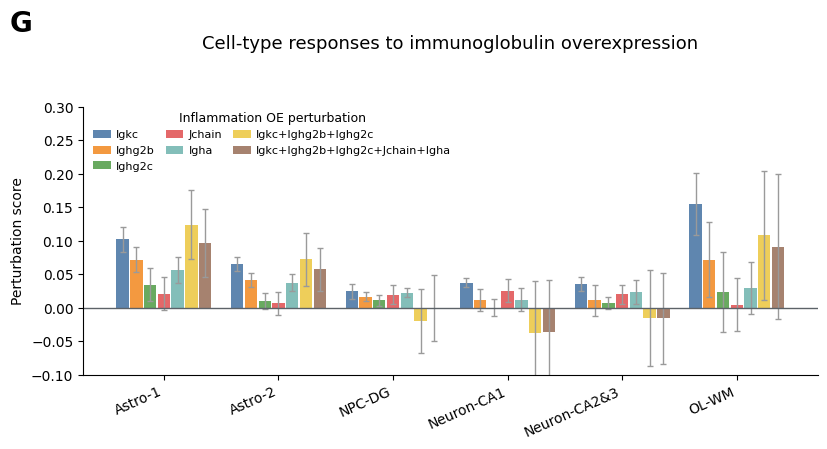

In [20]:
fig_g, ax_g = plt.subplots(figsize=G_FIGSIZE)
x_g = np.arange(len(G_CELLTYPES))
width_g = 0.84 / len(G_PERTURBATIONS)
for j, (perturbation,label,color) in enumerate(zip(G_PERTURBATIONS,G_LABELS,G_COLORS)):
    vals = g_summary[g_summary.perturbation.eq(perturbation)].set_index("celltype").loc[G_CELLTYPES]
    offset = (j - (len(G_PERTURBATIONS)-1)/2)*width_g
    ax_g.bar(x_g+offset, vals["mean"], yerr=vals["sem"], width=width_g*0.90,
        color=color, alpha=0.9, edgecolor="none", label=label,
        error_kw={"ecolor":"#9A9A9A","elinewidth":1.0,"capsize":2.5,"capthick":1.0})
ax_g.axhline(0,color="#5C6268",linewidth=1)
ax_g.set_xticks(x_g)
ax_g.set_xticklabels(G_CELLTYPES,rotation=24,ha="right")
ax_g.set_ylim(*G_YLIM)
ax_g.set_ylabel("Perturbation score")
ax_g.set_title("Cell-type responses to immunoglobulin overexpression",pad=42,fontsize=13)
ax_g.legend(title="Inflammation OE perturbation",ncol=3,frameon=False,
    loc="upper left",bbox_to_anchor=(0.0,1.02),fontsize=8,title_fontsize=9,
    handlelength=1.6,handletextpad=0.45,columnspacing=1.0)
ax_g.spines[["top","right"]].set_visible(False)
fig_g.subplots_adjust(left=0.10,right=0.985,bottom=0.21,top=0.78)
fig_g.text(0.012,0.94,"G",fontsize=20,fontweight="bold")
for ext in ["pdf","svg","png"]:
    fig_g.savefig(out_fig_dir / f"panel_G_immunoglobulin_OE.{ext}",bbox_inches="tight",dpi=300)
plt.show()


## Export manuscript panels

Save the PDF, editable SVG and PNG panels to a shared figure directory.

In [21]:
from shutil import copy2

maintext_dir = BASE_DIR / "tutorial" / "figures" / "aging_maintext"
maintext_dir.mkdir(parents=True, exist_ok=True)
maintext_panels = ['E', 'F', 'G']
exported_figures = []
for panel in maintext_panels:
    for path in sorted(out_fig_dir.glob(f"panel_{panel}_*")):
        if path.suffix in {".pdf", ".svg", ".png"}:
            target = maintext_dir / path.name
            copy2(path, target)
            exported_figures.append(target)
print(f"Saved {len(exported_figures)} figure files to {maintext_dir}")


Saved 9 figure files to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/figures/aging_maintext
